<a href="https://colab.research.google.com/github/FrankEHA/INGENIERIA_DEL_CONOCIMIENTO/blob/main/EJERCICIO_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Ejercicio 3 — Aplicación con dataset propio

**Dataset:** *Student Performance on an Entrance Examination* (UCI Machine Learning Repository).

**Contexto:** datos de candidatos que aprobaron el examen de ingreso a facultades de medicina de Assam (India), recopilados por el Prof. Jiten Hazarika. Incluyen género, casta, asistencia a academias, tipo de educación secundaria, porcentajes de las clases X y XII, ocupación de los padres y tiempo de estudio.

**Problema:** clasificación multiclase (4 clases) para predecir el nivel de desempeño del candidato: `Average`, `Good`, `Vg` o `Excellent`.

**Cumplimiento de requisitos:** 666 registros (622 únicos, mínimo 500) y 11 features (mínimo 5).

**Paso 0 — Configuración del entorno**

Se importan todas las librerías usadas en la sesión (más `ucimlrepo` para descargar el dataset) y se fija la semilla aleatoria para que los resultados sean reproducibles.

In [11]:
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)
from ucimlrepo import fetch_ucirepo

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


**Paso 1 — Carga del dataset**

Se descarga con `ucimlrepo` y se unen las features y el objetivo en un solo `DataFrame` (`df_ent`).

In [12]:
dataset = fetch_ucirepo(name='Student Performance on an Entrance Examination')
X_raw = dataset.data.features
y_raw = dataset.data.targets

df_ent = X_raw.copy()
df_ent['Performance'] = y_raw.iloc[:, 0]

print(f'Dataset cargado: {df_ent.shape[0]} registros, {df_ent.shape[1]} columnas '
      f'({df_ent.shape[1] - 1} features + 1 target)')
df_ent.head()

Dataset cargado: 666 registros, 12 columnas (11 features + 1 target)


,Gender,Caste,coaching,Class_ten_education,twelve_education,medium,Class_X_Percentage,Class_XII_Percentage,Father_occupation,Mother_occupation,time,Performance
0,male,General,NO,SEBA,AHSEC,ENGLISH,Excellent,Excellent,DOCTOR,OTHERS,ONE,Excellent
1,male,OBC,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,HOUSE_WIFE,TWO,Excellent
2,male,OBC,OA,OTHERS,CBSE,ENGLISH,Excellent,Excellent,BUSINESS,HOUSE_WIFE,TWO,Excellent
3,male,General,WA,SEBA,AHSEC,OTHERS,Excellent,Excellent,SCHOOL_TEACHER,SCHOOL_TEACHER,ONE,Excellent
4,male,General,OA,SEBA,CBSE,ENGLISH,Excellent,Excellent,COLLEGE_TEACHER,HOUSE_WIFE,TWO,Excellent


**Paso 2 — Exploración inicial**

Se revisa: (1) la distribución de las 4 clases, para medir el desbalance; (2) las categorías de cada variable, para decidir cómo codificarlas; (3) valores faltantes; y (4) filas duplicadas por clase, para decidir cómo tratarlas antes del split.

In [13]:
# 2.1 Distribución del target
orden_p = ['Average', 'Good', 'Vg', 'Excellent']
conteo = df_ent['Performance'].value_counts().reindex(orden_p)
porc = (conteo / len(df_ent) * 100).round(1)
print('Distribución de la variable objetivo:')
display(pd.DataFrame({'Cantidad': conteo, '% del total': porc}))
print(f'Ratio de desbalance (mayoritaria : minoritaria) = {conteo.max() / conteo.min():.2f} : 1')

# 2.2 Categorías de cada variable
print('\nCategorías de cada variable:')
for col in df_ent.columns.drop('Performance'):
    print(f'  {col:22s} ({df_ent[col].nunique()}): {sorted(df_ent[col].unique())}')

# 2.3 Faltantes
print(f'\nValores faltantes totales: {df_ent.isna().sum().sum()}')

# 2.4 Duplicados por clase
dup_clase = pd.DataFrame({
    'Total': df_ent['Performance'].value_counts(),
    'Copias repetidas': df_ent[df_ent.duplicated()]['Performance'].value_counts(),
}).fillna(0).astype(int).reindex(orden_p)
dup_clase['Únicas'] = dup_clase['Total'] - dup_clase['Copias repetidas']
print('\nDuplicados por clase:')
display(dup_clase)

Distribución de la variable objetivo:


,Cantidad,% del total
Performance,,
Average,157,23.6
Good,210,31.5
Vg,198,29.7
Excellent,101,15.2


Ratio de desbalance (mayoritaria : minoritaria) = 2.08 : 1

Categorías de cada variable:
  Gender                 (2): ['female', 'male']
  Caste                  (4): ['General', 'OBC', 'SC', 'ST']
  coaching               (3): ['NO', 'OA', 'WA']
  Class_ten_education    (3): ['CBSE', 'OTHERS', 'SEBA']
  twelve_education       (3): ['AHSEC', 'CBSE', 'OTHERS']
  medium                 (3): ['ASSAMESE', 'ENGLISH', 'OTHERS']
  Class_X_Percentage     (4): ['Average', 'Excellent', 'Good', 'Vg']
  Class_XII_Percentage   (4): ['Average', 'Excellent', 'Good', 'Vg']
  Father_occupation      (8): ['BANK_OFFICIAL', 'BUSINESS', 'COLLEGE_TEACHER', 'CULTIVATOR', 'DOCTOR', 'ENGINEER', 'OTHERS', 'SCHOOL_TEACHER']
  Mother_occupation      (9): ['BANK_OFFICIAL', 'BUSINESS', 'COLLEGE_TEACHER', 'CULTIVATOR', 'DOCTOR', 'ENGINEER', 'HOUSE_WIFE', 'OTHERS', 'SCHOOL_TEACHER']
  time                   (6): ['FIVE', 'FOUR', 'ONE', 'SEVEN', 'THREE', 'TWO']

Valores faltantes totales: 0

Duplicados por clase:


,Total,Copias repetidas,Únicas
Performance,,,
Average,157,5,152
Good,210,16,194
Vg,198,20,178
Excellent,101,3,98


**Paso 3 — Tipos de variables y tratamiento de duplicados**

Se separan las 11 features en dos grupos:

- **Ordinales:** `Class_X_Percentage`, `Class_XII_Percentage` (`Average` < `Good` < `Vg` < `Excellent`) y `time` (`ONE` < `TWO` < ... < `SEVEN`). Tienen un orden natural, así que se codificarán como números que respeten ese orden.
- **Nominales:** las otras 8 (género, casta, tipo de coaching, tipo de educación, idioma y ocupación de los padres). No tienen orden, así que se codificarán con one-hot.

También se verifica si hay filas con las mismas features pero distinta clase (etiquetas contradictorias) y se elimina la copia repetida de las filas duplicadas. El dataset resultante es `df_ent_u`.

In [14]:
orden_p = ['Average', 'Good', 'Vg', 'Excellent']

cols_ordinales = ['Class_X_Percentage', 'Class_XII_Percentage', 'time']
cols_nominales = ['Gender', 'Caste', 'coaching', 'Class_ten_education',
                  'twelve_education', 'medium', 'Father_occupation', 'Mother_occupation']
features_ent = [c for c in df_ent.columns if c != 'Performance']

# Verificación: todas las features quedan en un solo grupo
assert set(cols_ordinales + cols_nominales) == set(features_ent)
print(f'Ordinales: {len(cols_ordinales)}  |  Nominales: {len(cols_nominales)}  |  Total: {len(features_ent)}')

# Columnas resultantes tras la codificación
n_onehot = df_ent[cols_nominales].nunique().sum()
print(f'Columnas del one-hot (nominales): {n_onehot}')
print(f'Total de features tras la codificación: {n_onehot + len(cols_ordinales)}')

# 3.1 Etiquetas contradictorias (mismas features, distinta clase)
conf = df_ent.drop_duplicates().groupby(features_ent)['Performance'].nunique()
print(f'\nCombinaciones de features con más de una etiqueta: {(conf > 1).sum()}')

# 3.2 Eliminación de duplicados
df_ent_u = df_ent.drop_duplicates().reset_index(drop=True)
print(f'\nRegistros antes: {len(df_ent)}  |  después: {len(df_ent_u)}')

conteo_u = df_ent_u['Performance'].value_counts().reindex(orden_p)
display(pd.DataFrame({'Cantidad': conteo_u,
                      '% del total': (conteo_u / len(df_ent_u) * 100).round(1)}))
print(f'Ratio de desbalance tras limpiar: {conteo_u.max() / conteo_u.min():.2f} : 1')

Ordinales: 3  |  Nominales: 8  |  Total: 11
Columnas del one-hot (nominales): 35
Total de features tras la codificación: 38

Combinaciones de features con más de una etiqueta: 42

Registros antes: 666  |  después: 622


,Cantidad,% del total
Performance,,
Average,152,24.4
Good,194,31.2
Vg,178,28.6
Excellent,98,15.8


Ratio de desbalance tras limpiar: 1.98 : 1


**Paso 4 — Relación de cada variable con el desempeño**

Para saber qué variables aportan más información, se calcula la **V de Cramér** entre cada feature y `Performance` (0 = sin relación, 1 = relación perfecta). Luego se grafica, para seis variables clave, el porcentaje de estudiantes de cada categoría en cada nivel de desempeño.

V de Cramér (feature vs. Performance):


,V de Cramér
Caste,0.468
Class_XII_Percentage,0.185
Father_occupation,0.185
Mother_occupation,0.158
Class_X_Percentage,0.142
medium,0.142
coaching,0.139
Class_ten_education,0.102
time,0.098
Gender,0.093


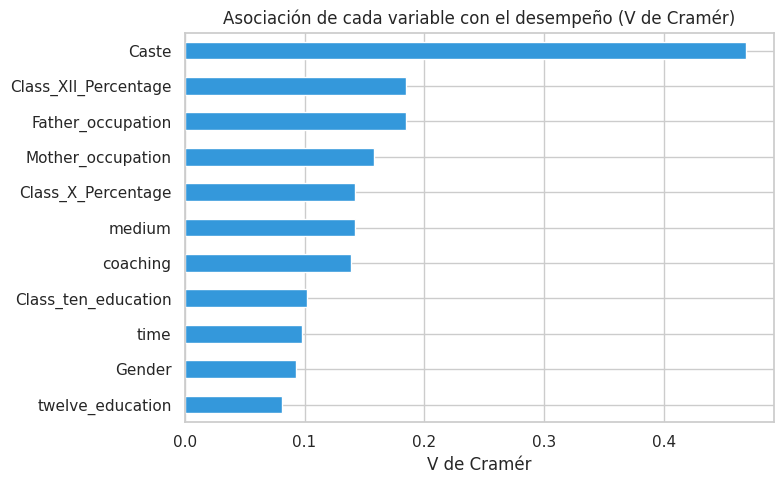

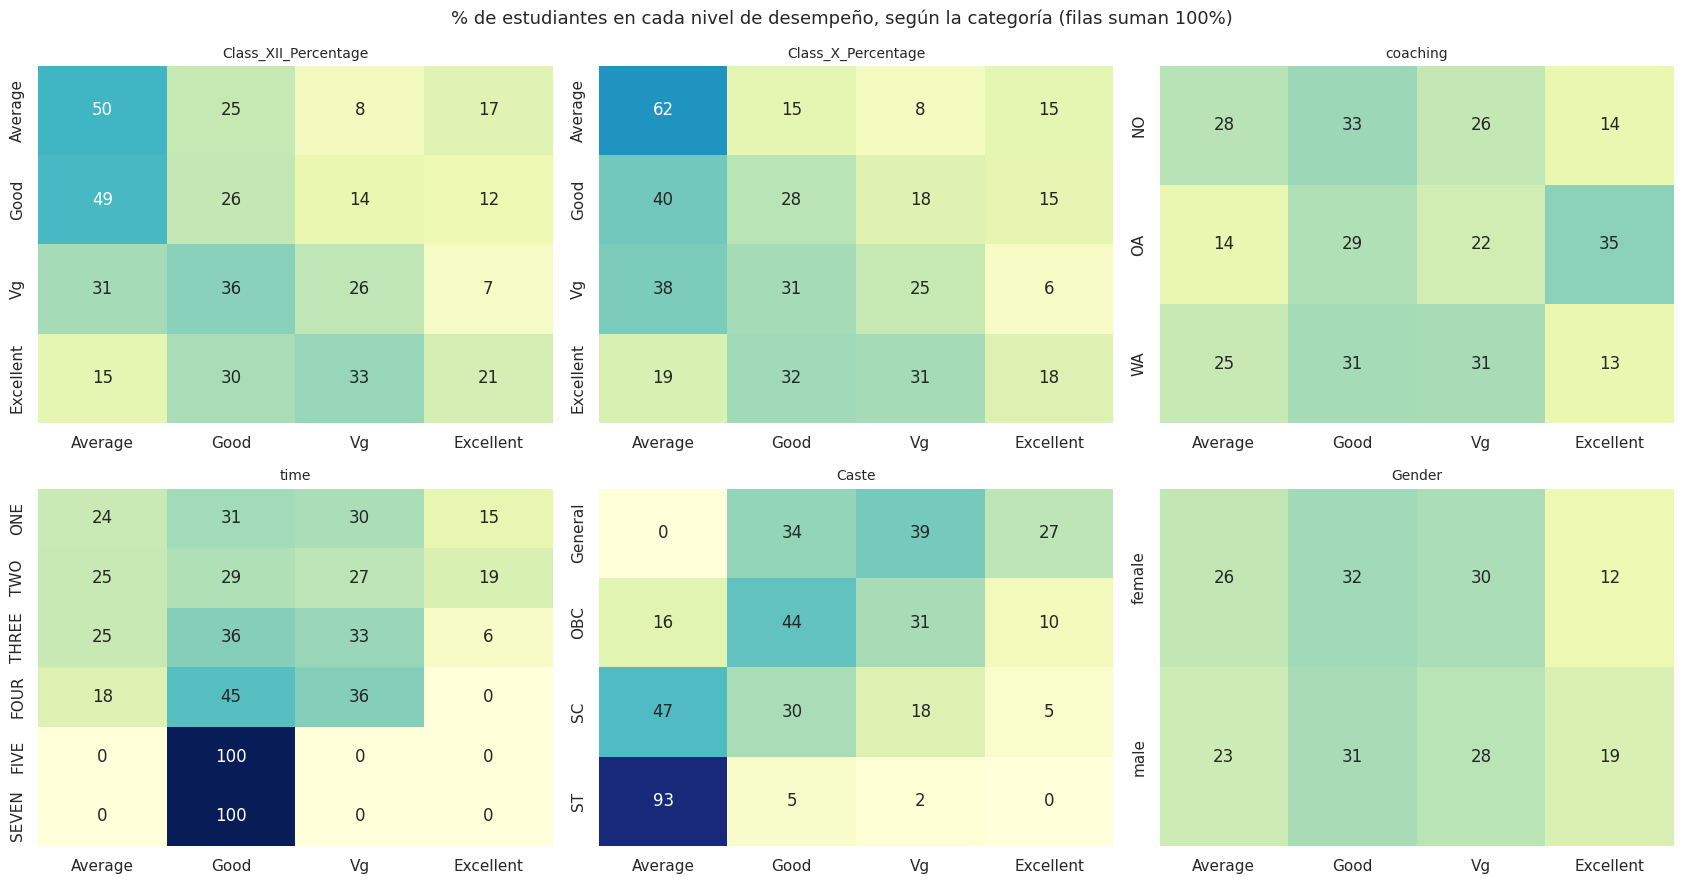

In [15]:
from scipy.stats import chi2_contingency

# 4.1 V de Cramér de cada feature contra el target
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.values.sum()
    r, k = tabla.shape
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

v_cramer = pd.Series(
    {c: cramers_v(df_ent_u[c], df_ent_u['Performance']) for c in features_ent}
).sort_values(ascending=False)

print('V de Cramér (feature vs. Performance):')
display(v_cramer.round(3).to_frame('V de Cramér'))

fig, ax = plt.subplots(figsize=(8, 5))
v_cramer.sort_values().plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Asociación de cada variable con el desempeño (V de Cramér)')
ax.set_xlabel('V de Cramér')
plt.tight_layout()
plt.show()

# 4.2 Perfil por clase de seis variables clave (% dentro de cada categoría)
vars_clave = ['Class_XII_Percentage', 'Class_X_Percentage', 'coaching',
              'time', 'Caste', 'Gender']
orden_cat = {
    'Class_XII_Percentage': orden_p,
    'Class_X_Percentage': orden_p,
    'time': ['ONE', 'TWO', 'THREE', 'FOUR', 'FIVE', 'SEVEN']
}

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()
for ax, col in zip(axes, vars_clave):
    tabla = pd.crosstab(df_ent_u[col], df_ent_u['Performance'], normalize='index') * 100
    tabla = tabla[orden_p]
    if col in orden_cat:
        tabla = tabla.reindex(orden_cat[col])
    sns.heatmap(tabla, annot=True, fmt='.0f', cmap='YlGnBu', vmin=0, vmax=100,
                cbar=False, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
fig.suptitle('% de estudiantes en cada nivel de desempeño, según la categoría (filas suman 100%)',
             fontsize=13)
plt.tight_layout()
plt.show()

**Paso 5 — División train/test y preprocesamiento**

Se hace un split estratificado 80/20 (igual que en la sesión) sobre el dataset sin duplicados, para mantener la proporción de las 4 clases en ambos conjuntos. Como la clase `Excellent` es pequeña (98 filas), el test tendrá pocas muestras de ella, por lo que se apoyará el análisis en la validación cruzada.

El preprocesamiento se define con un `ColumnTransformer` que aplica a cada grupo lo que le corresponde:

- **Ordinales:** `OrdinalEncoder` con el orden explícito de las categorías y luego `StandardScaler`, para que sus escalas sean comparables con las demás.
- **Nominales:** `OneHotEncoder`.

El preprocesador se incluirá dentro de cada `Pipeline`, de modo que en la validación cruzada se ajuste solo con los datos de entrenamiento de cada fold, sin fuga de información.

In [16]:
# 5.1 Separación features / target y split estratificado 80/20
X_ent = df_ent_u[features_ent].copy()
y_ent = df_ent_u['Performance'].copy()

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_ent, y_ent, test_size=0.20, random_state=RANDOM_STATE, stratify=y_ent
)

print(f'Train: {X_train_e.shape[0]} muestras  |  Test: {X_test_e.shape[0]} muestras')
dist_split = pd.DataFrame({
    'Train': y_train_e.value_counts().reindex(orden_p),
    'Test': y_test_e.value_counts().reindex(orden_p),
    'Train (%)': (y_train_e.value_counts(normalize=True).reindex(orden_p) * 100).round(1),
    'Test (%)': (y_test_e.value_counts(normalize=True).reindex(orden_p) * 100).round(1)
})
display(dist_split)

# 5.2 Preprocesador
orden_time = ['ONE', 'TWO', 'THREE', 'FOUR', 'FIVE', 'SEVEN']

ord_pipe = Pipeline([
    ('ord', OrdinalEncoder(categories=[orden_p, orden_p, orden_time])),
    ('scaler', StandardScaler())
])

preprocesador = ColumnTransformer([
    ('ord', ord_pipe, cols_ordinales),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_nominales)
])

# 5.3 Validación cruzada estratificada (la misma para todos los modelos)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 5.4 Ajuste solo para verificar (no se usa después)
Xt = preprocesador.fit_transform(X_train_e)
print(f'\nColumnas tras el preprocesamiento: {Xt.shape[1]}')
print('Primeras columnas:', list(preprocesador.get_feature_names_out()[:6]))

Train: 497 muestras  |  Test: 125 muestras


,Train,Test,Train (%),Test (%)
Performance,,,,
Average,122,30,24.5,24.0
Good,155,39,31.2,31.2
Vg,142,36,28.6,28.8
Excellent,78,20,15.7,16.0



Columnas tras el preprocesamiento: 38
Primeras columnas: ['ord__Class_X_Percentage', 'ord__Class_XII_Percentage', 'ord__time', 'nom__Gender_female', 'nom__Gender_male', 'nom__Caste_General']


**Paso 6 — Modelo 1: Regresión Logística**

Se construye un `Pipeline` con el preprocesador y una `LogisticRegression` multinomial con `class_weight='balanced'` para compensar el desbalance. Se evalúa con validación cruzada estratificada de 5 folds, usando **F1 macro** como métrica principal (todas las clases pesan igual). Después se entrena con todo el train y se evalúa en test.

Los resultados se guardan en diccionarios (`resultados_cv` y `pred_test`) para armar la comparación final de los 4 modelos. Como referencia, un modelo que siempre prediga la clase mayoritaria (`Good`) obtendría un accuracy cercano al 31%.

Accuracy de referencia (siempre la clase mayoritaria): 0.3120

Logistic Regression — F1 macro CV: 0.4664 ± 0.0385
Accuracy test: 0.5360
F1 macro test: 0.5259

Classification report (test):
              precision    recall  f1-score   support

     Average       0.72      0.87      0.79        30
        Good       0.52      0.31      0.39        39
          Vg       0.51      0.53      0.52        36
   Excellent       0.34      0.50      0.41        20

    accuracy                           0.54       125
   macro avg       0.53      0.55      0.53       125
weighted avg       0.54      0.54      0.53       125



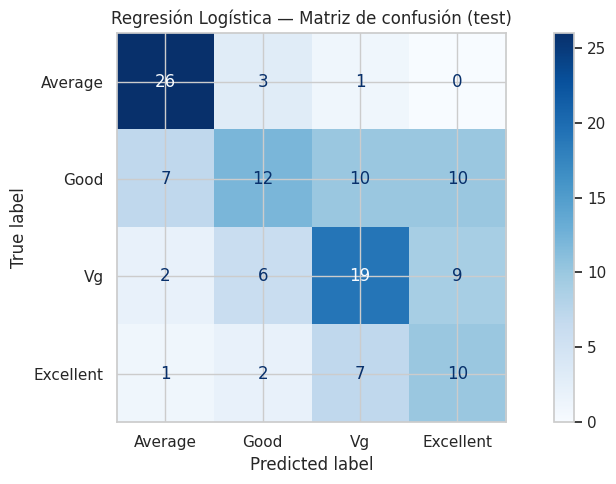

In [17]:
from sklearn.base import clone

resultados_cv = {}
pred_test = {}

# Referencia: predecir siempre la clase mayoritaria
baseline_acc = y_test_e.value_counts(normalize=True).max()
print(f'Accuracy de referencia (siempre la clase mayoritaria): {baseline_acc:.4f}')

# 6.1 Pipeline
pipe_lr = Pipeline([
    ('prep', clone(preprocesador)),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                               random_state=RANDOM_STATE))
])

# 6.2 Validación cruzada
scores_lr = cross_val_score(pipe_lr, X_train_e, y_train_e, cv=cv, scoring='f1_macro')
print(f'\nLogistic Regression — F1 macro CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# 6.3 Entrenamiento final y evaluación en test
pipe_lr.fit(X_train_e, y_train_e)
y_pred_lr = pipe_lr.predict(X_test_e)

resultados_cv['Logistic Regression'] = scores_lr
pred_test['Logistic Regression'] = y_pred_lr

print(f'Accuracy test: {accuracy_score(y_test_e, y_pred_lr):.4f}')
print(f"F1 macro test: {f1_score(y_test_e, y_pred_lr, average='macro'):.4f}")

print('\nClassification report (test):')
print(classification_report(y_test_e, y_pred_lr, labels=orden_p, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test_e, y_pred_lr, labels=orden_p, cmap='Blues'
)
plt.title('Regresión Logística — Matriz de confusión (test)')
plt.tight_layout()
plt.show()

**Paso 7 — Interpretación de los coeficientes**

La regresión logística multinomial tiene un vector de coeficientes por clase. Se muestran en un mapa de calor las 15 variables con mayor coeficiente absoluto: un valor positivo indica que la variable aumenta la probabilidad de esa clase, y uno negativo que la reduce. Las variables ya están en una escala comparable (ordinales estandarizadas y one-hot), así que sus magnitudes se pueden comparar.

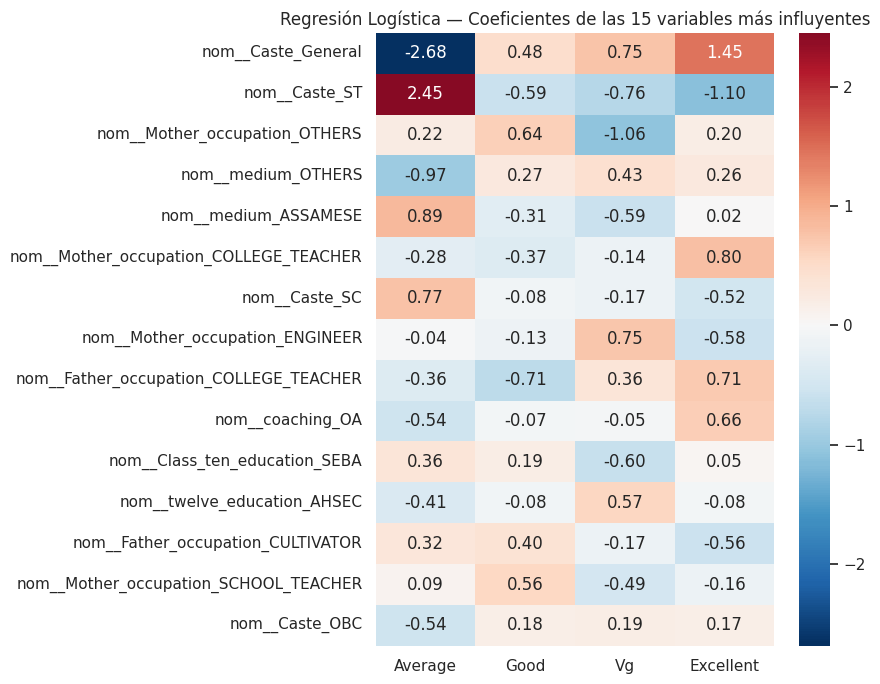

Variables más influyentes (coeficiente absoluto máximo):


,|coef| máx
nom__Caste_General,2.684
nom__Caste_ST,2.450
nom__Mother_occupation_OTHERS,1.060
nom__medium_OTHERS,0.970
nom__medium_ASSAMESE,0.885
nom__Mother_occupation_COLLEGE_TEACHER,0.795
nom__Caste_SC,0.769
nom__Mother_occupation_ENGINEER,0.745
nom__Father_occupation_COLLEGE_TEACHER,0.708
nom__coaching_OA,0.664


In [18]:
clf_lr = pipe_lr.named_steps['clf']
nombres = pipe_lr.named_steps['prep'].get_feature_names_out()

coef = pd.DataFrame(clf_lr.coef_, index=clf_lr.classes_, columns=nombres).T
coef = coef[orden_p]

top15 = coef.abs().max(axis=1).sort_values(ascending=False).head(15).index

plt.figure(figsize=(9, 7))
sns.heatmap(coef.loc[top15], annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Regresión Logística — Coeficientes de las 15 variables más influyentes')
plt.tight_layout()
plt.show()

print('Variables más influyentes (coeficiente absoluto máximo):')
display(coef.abs().max(axis=1).sort_values(ascending=False).head(10).round(3).to_frame('|coef| máx'))

**Paso 8 — Modelo 2: Árbol de Decisión**

Se usa la misma configuración de la sesión (`max_depth=5`, `min_samples_leaf=10`, `class_weight='balanced'`) dentro de un `Pipeline` con el mismo preprocesador. Se evalúa con validación cruzada (F1 macro) y en test, y los resultados se guardan en `resultados_cv` y `pred_test` para la comparación final. Un árbol no necesita estandarización, pero mantener el preprocesador no lo perjudica y simplifica el código.

Decision Tree — F1 macro CV: 0.4079 ± 0.0189
Accuracy test: 0.4800
F1 macro test: 0.4594

Classification report (test):
              precision    recall  f1-score   support

     Average       0.66      0.90      0.76        30
        Good       0.59      0.26      0.36        39
          Vg       0.44      0.19      0.27        36
   Excellent       0.31      0.80      0.45        20

    accuracy                           0.48       125
   macro avg       0.50      0.54      0.46       125
weighted avg       0.52      0.48      0.44       125



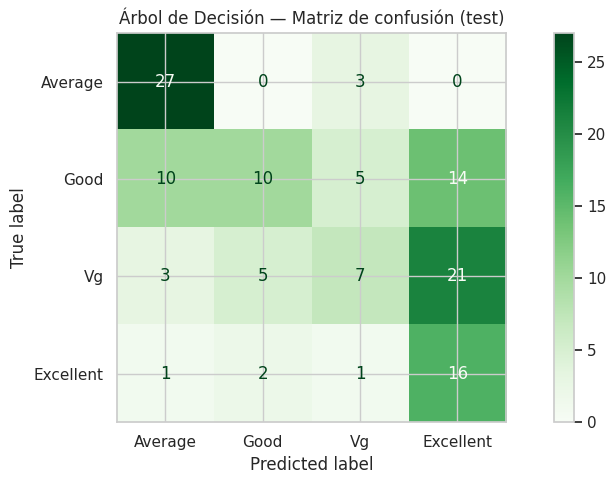

In [19]:
# 8.1 Pipeline
pipe_dt = Pipeline([
    ('prep', clone(preprocesador)),
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                   class_weight='balanced', random_state=RANDOM_STATE))
])

# 8.2 Validación cruzada
scores_dt = cross_val_score(pipe_dt, X_train_e, y_train_e, cv=cv, scoring='f1_macro')
print(f'Decision Tree — F1 macro CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

# 8.3 Entrenamiento final y evaluación en test
pipe_dt.fit(X_train_e, y_train_e)
y_pred_dt = pipe_dt.predict(X_test_e)

resultados_cv['Decision Tree'] = scores_dt
pred_test['Decision Tree'] = y_pred_dt

print(f'Accuracy test: {accuracy_score(y_test_e, y_pred_dt):.4f}')
print(f"F1 macro test: {f1_score(y_test_e, y_pred_dt, average='macro'):.4f}")

print('\nClassification report (test):')
print(classification_report(y_test_e, y_pred_dt, labels=orden_p, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test_e, y_pred_dt, labels=orden_p, cmap='Greens'
)
plt.title('Árbol de Decisión — Matriz de confusión (test)')
plt.tight_layout()
plt.show()

**Paso 9 — Efecto de la profundidad e importancia de las variables**

Primero se compara el F1 macro en train y en validación cruzada para profundidades de 1 a 15. Cuando la brecha entre ambas curvas crece, el árbol está sobreajustando. Luego se calcula la importancia (Gini) de cada variable original, sumando la importancia de todas las columnas del one-hot que provienen de ella.

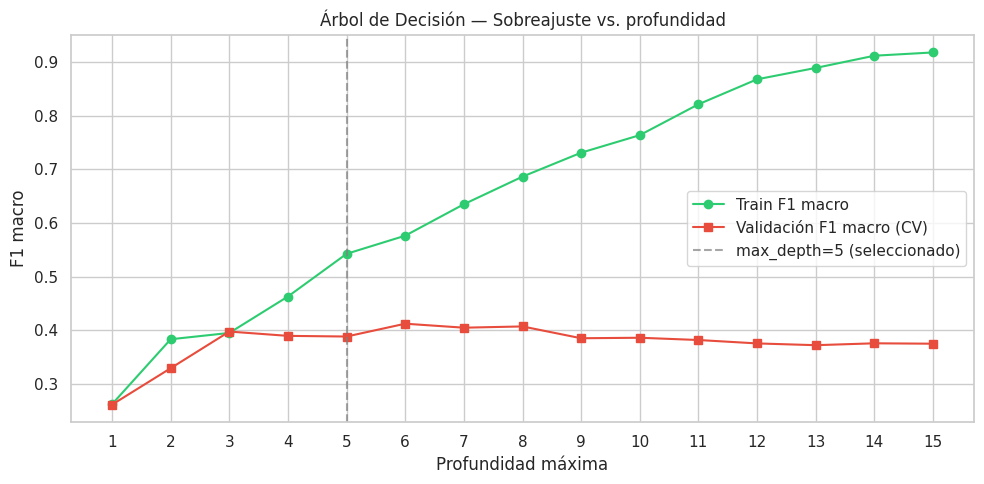

Mejor profundidad según F1 macro CV: 6 (F1 = 0.4121)


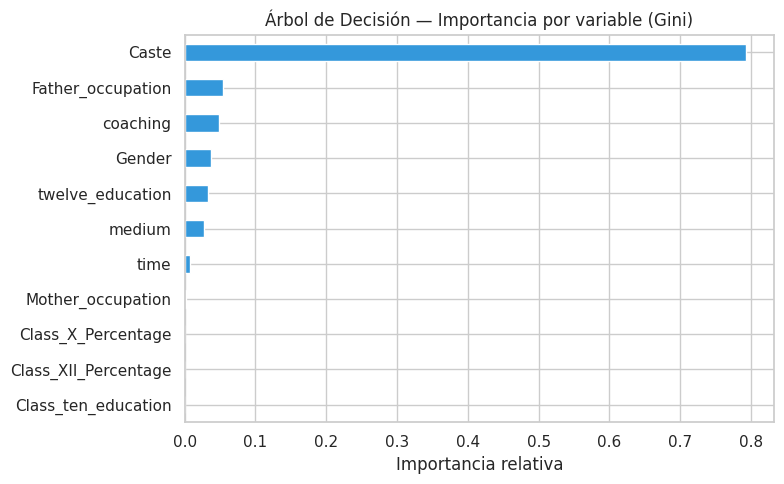

,Importancia
Caste,0.793
Father_occupation,0.053
coaching,0.048
Gender,0.037
twelve_education,0.032
medium,0.027
time,0.008
Mother_occupation,0.002
Class_X_Percentage,0.000
Class_XII_Percentage,0.000


In [20]:
# 9.1 Profundidad vs. sobreajuste
depths = range(1, 16)
train_sc, val_sc = [], []

for d in depths:
    p = Pipeline([
        ('prep', clone(preprocesador)),
        ('clf', DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                       random_state=RANDOM_STATE))
    ])
    p.fit(X_train_e, y_train_e)
    train_sc.append(f1_score(y_train_e, p.predict(X_train_e), average='macro'))
    val_sc.append(cross_val_score(p, X_train_e, y_train_e, cv=cv, scoring='f1_macro').mean())

mejor_d = list(depths)[int(np.argmax(val_sc))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_sc, 'o-', label='Train F1 macro', color='#2ecc71')
ax.plot(depths, val_sc, 's-', label='Validación F1 macro (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1 macro')
ax.set_title('Árbol de Decisión — Sobreajuste vs. profundidad')
ax.set_xticks(list(depths))
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor profundidad según F1 macro CV: {mejor_d} (F1 = {max(val_sc):.4f})')

# 9.2 Importancia agregada por variable original
imp = pd.Series(pipe_dt.named_steps['clf'].feature_importances_,
                index=pipe_dt.named_steps['prep'].get_feature_names_out())

def variable_original(nombre):
    for c in features_ent:
        if nombre == f'ord__{c}' or nombre.startswith(f'nom__{c}_'):
            return c

imp_var = imp.groupby(variable_original).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
imp_var.sort_values().plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia por variable (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

display(imp_var.round(3).to_frame('Importancia'))

**Paso 10 — Modelo 3: Support Vector Machine (SVM)**

Se comparan tres kernels (`linear`, `rbf` y `poly`) con `class_weight='balanced'`, usando el mismo preprocesador y F1 macro en validación cruzada. Se elige el mejor kernel, se entrena con todo el train y se evalúa en test. No se usa `probability=True` porque no se necesita y hace el entrenamiento más lento.

SVM (linear) — F1 macro CV: 0.4545 ± 0.0544
SVM (rbf   ) — F1 macro CV: 0.4881 ± 0.0400
SVM (poly  ) — F1 macro CV: 0.4536 ± 0.0534

Mejor kernel: rbf

Accuracy test: 0.4720
F1 macro test: 0.4619

Classification report (test):
              precision    recall  f1-score   support

     Average       0.70      0.87      0.78        30
        Good       0.44      0.38      0.41        39
          Vg       0.33      0.19      0.25        36
   Excellent       0.33      0.55      0.42        20

    accuracy                           0.47       125
   macro avg       0.45      0.50      0.46       125
weighted avg       0.46      0.47      0.45       125



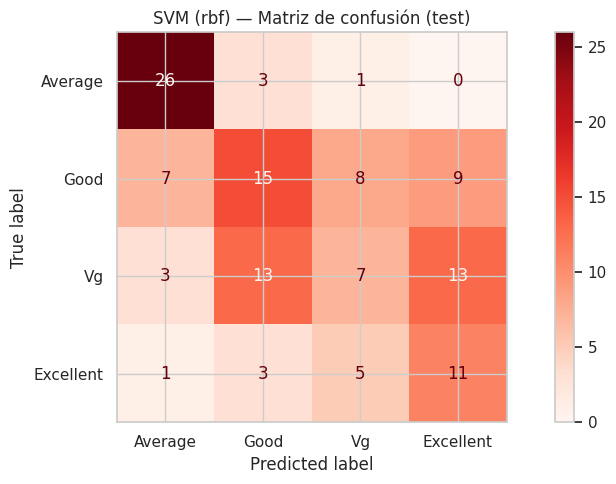

In [21]:
# 10.1 Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_cv = {}

for k in kernels:
    p = Pipeline([
        ('prep', clone(preprocesador)),
        ('clf', SVC(kernel=k, class_weight='balanced', random_state=RANDOM_STATE))
    ])
    svm_cv[k] = cross_val_score(p, X_train_e, y_train_e, cv=cv, scoring='f1_macro')
    print(f'SVM ({k:6s}) — F1 macro CV: {svm_cv[k].mean():.4f} ± {svm_cv[k].std():.4f}')

best_kernel_e = max(svm_cv, key=lambda k: svm_cv[k].mean())
print(f'\nMejor kernel: {best_kernel_e}')

# 10.2 Entrenamiento final con el mejor kernel
nombre_svm = f'SVM ({best_kernel_e})'
pipe_svm = Pipeline([
    ('prep', clone(preprocesador)),
    ('clf', SVC(kernel=best_kernel_e, class_weight='balanced', random_state=RANDOM_STATE))
])
pipe_svm.fit(X_train_e, y_train_e)
y_pred_svm = pipe_svm.predict(X_test_e)

resultados_cv[nombre_svm] = svm_cv[best_kernel_e]
pred_test[nombre_svm] = y_pred_svm

print(f'\nAccuracy test: {accuracy_score(y_test_e, y_pred_svm):.4f}')
print(f"F1 macro test: {f1_score(y_test_e, y_pred_svm, average='macro'):.4f}")

print('\nClassification report (test):')
print(classification_report(y_test_e, y_pred_svm, labels=orden_p, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test_e, y_pred_svm, labels=orden_p, cmap='Reds'
)
plt.title(f'{nombre_svm} — Matriz de confusión (test)')
plt.tight_layout()
plt.show()

**Paso 11 — Impacto de la estandarización en SVM**

En la sesión, quitar el `StandardScaler` hundió el F1 del SVM. Aquí el efecto debería ser mucho menor: las 35 columnas del one-hot ya valen 0 o 1, así que la estandarización solo cambia las 3 columnas ordinales. Se compara el mismo SVM con y sin estandarizar esas columnas para comprobarlo.

In [22]:
# Preprocesador sin estandarización (solo codificación)
prep_sin_esc = ColumnTransformer([
    ('ord', OrdinalEncoder(categories=[orden_p, orden_p, orden_time]), cols_ordinales),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_nominales)
])

svm_sin_esc = Pipeline([
    ('prep', prep_sin_esc),
    ('clf', SVC(kernel=best_kernel_e, class_weight='balanced', random_state=RANDOM_STATE))
])
scores_sin_esc = cross_val_score(svm_sin_esc, X_train_e, y_train_e, cv=cv, scoring='f1_macro')

con_esc = resultados_cv[nombre_svm].mean()
print('Impacto de la estandarización en SVM (solo afecta a las 3 columnas ordinales):')
print(f'  CON StandardScaler: F1 macro CV = {con_esc:.4f}')
print(f'  SIN StandardScaler: F1 macro CV = {scores_sin_esc.mean():.4f}')
print(f'  Diferencia: {(con_esc - scores_sin_esc.mean())*100:+.2f} puntos porcentuales')

Impacto de la estandarización en SVM (solo afecta a las 3 columnas ordinales):
  CON StandardScaler: F1 macro CV = 0.4881
  SIN StandardScaler: F1 macro CV = 0.4731
  Diferencia: +1.50 puntos porcentuales


**Paso 12 — Modelo 4: K-Nearest Neighbors (KNN), búsqueda del K óptimo**

Se prueban valores de K de 1 a 30, con el mismo preprocesador y F1 macro en validación cruzada. Con variables categóricas codificadas en one-hot, las distancias toman pocos valores distintos y hay muchos empates entre vecinos, así que se espera una curva irregular. Se grafica el F1 macro medio con una banda de ± 1 desviación estándar para juzgar si las diferencias entre valores de K son significativas.

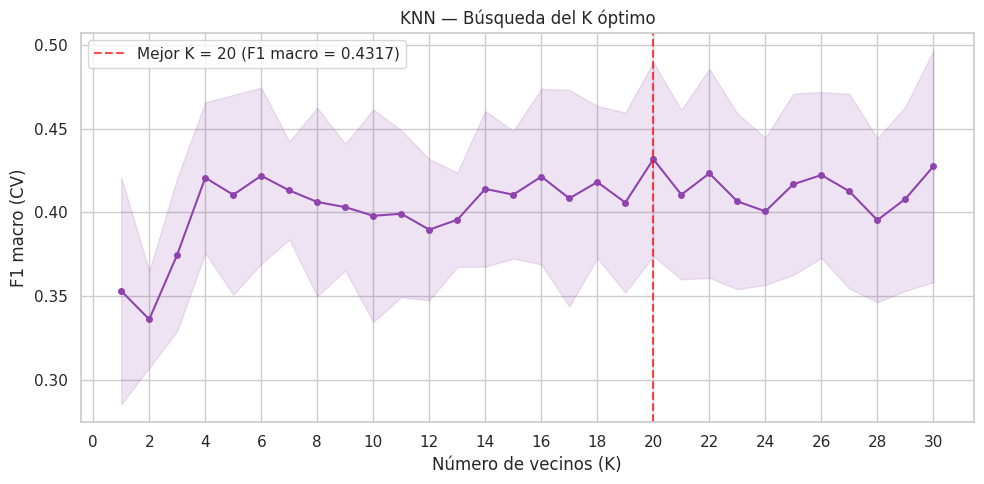

K óptimo: 20  (F1 macro CV = 0.4317 ± 0.0578)

Top 5 valores de K:


,K,F1 macro CV,std
0,20,0.4317,0.0578
1,30,0.4274,0.0691
2,22,0.4233,0.0623
3,26,0.4223,0.0494
4,6,0.4218,0.0525


In [23]:
k_range = range(1, 31)
k_medias, k_stds = [], []

for k in k_range:
    p = Pipeline([
        ('prep', clone(preprocesador)),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    s = cross_val_score(p, X_train_e, y_train_e, cv=cv, scoring='f1_macro')
    k_medias.append(s.mean())
    k_stds.append(s.std())

k_medias = np.array(k_medias)
k_stds = np.array(k_stds)
best_k_e = list(k_range)[int(np.argmax(k_medias))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_medias, 'o-', markersize=4, color='#8e44ad')
ax.fill_between(k_range, k_medias - k_stds, k_medias + k_stds, alpha=0.15, color='#8e44ad')
ax.axvline(x=best_k_e, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k_e} (F1 macro = {k_medias.max():.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1 macro (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.set_xticks(range(0, 31, 2))
ax.legend()
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k_e}  (F1 macro CV = {k_medias.max():.4f} ± {k_stds[np.argmax(k_medias)]:.4f})')
print('\nTop 5 valores de K:')
top5 = pd.DataFrame({'K': list(k_range), 'F1 macro CV': k_medias.round(4), 'std': k_stds.round(4)})
display(top5.sort_values('F1 macro CV', ascending=False).head(5).reset_index(drop=True))

**Paso 13 — Entrenamiento y evaluación de KNN con el K óptimo**

Se entrena KNN con el K elegido, se evalúa en test y se guardan los resultados para la comparación final. KNN no tiene parámetro `class_weight`, así que no compensa el desbalance: es esperable que favorezca a las clases más frecuentes.

KNN (K=20) — F1 macro CV: 0.4317 ± 0.0578
Accuracy test: 0.4400
F1 macro test: 0.4327

Classification report (test):
              precision    recall  f1-score   support

     Average       0.70      0.77      0.73        30
        Good       0.40      0.46      0.43        39
          Vg       0.26      0.22      0.24        36
   Excellent       0.38      0.30      0.33        20

    accuracy                           0.44       125
   macro avg       0.43      0.44      0.43       125
weighted avg       0.43      0.44      0.43       125



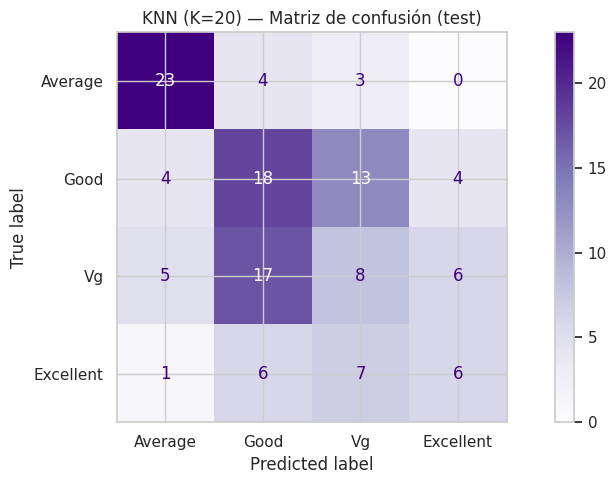

In [24]:
nombre_knn = f'KNN (K={best_k_e})'
pipe_knn = Pipeline([
    ('prep', clone(preprocesador)),
    ('clf', KNeighborsClassifier(n_neighbors=best_k_e))
])

scores_knn = cross_val_score(pipe_knn, X_train_e, y_train_e, cv=cv, scoring='f1_macro')
print(f'{nombre_knn} — F1 macro CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train_e, y_train_e)
y_pred_knn = pipe_knn.predict(X_test_e)

resultados_cv[nombre_knn] = scores_knn
pred_test[nombre_knn] = y_pred_knn

print(f'Accuracy test: {accuracy_score(y_test_e, y_pred_knn):.4f}')
print(f"F1 macro test: {f1_score(y_test_e, y_pred_knn, average='macro'):.4f}")

print('\nClassification report (test):')
print(classification_report(y_test_e, y_pred_knn, labels=orden_p, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test_e, y_pred_knn, labels=orden_p, cmap='Purples'
)
plt.title(f'{nombre_knn} — Matriz de confusión (test)')
plt.tight_layout()
plt.show()

**Paso 14 — Tabla comparativa y validación cruzada de los 4 modelos**

Se reúnen los resultados de los 4 modelos en una tabla: F1 macro en validación cruzada (media y desviación estándar), y accuracy, F1 macro y F1 weighted en test. Luego se grafica la distribución del F1 macro de los 5 folds de cada modelo. Si las cajas se solapan, la diferencia entre esos modelos no es concluyente.

COMPARACIÓN DE MODELOS
Referencia (siempre la clase mayoritaria): accuracy = 0.3120


,F1 macro CV (media),F1 macro CV (std),Accuracy test,F1 macro test,F1 weighted test
Modelo,,,,,
Logistic Regression,0.466400,0.038500,0.536000,0.525900,0.525100
Decision Tree,0.407900,0.018900,0.480000,0.459400,0.443600
SVM (rbf),0.488100,0.040000,0.472000,0.461900,0.451600
KNN (K=20),0.431700,0.057800,0.440000,0.432700,0.431100


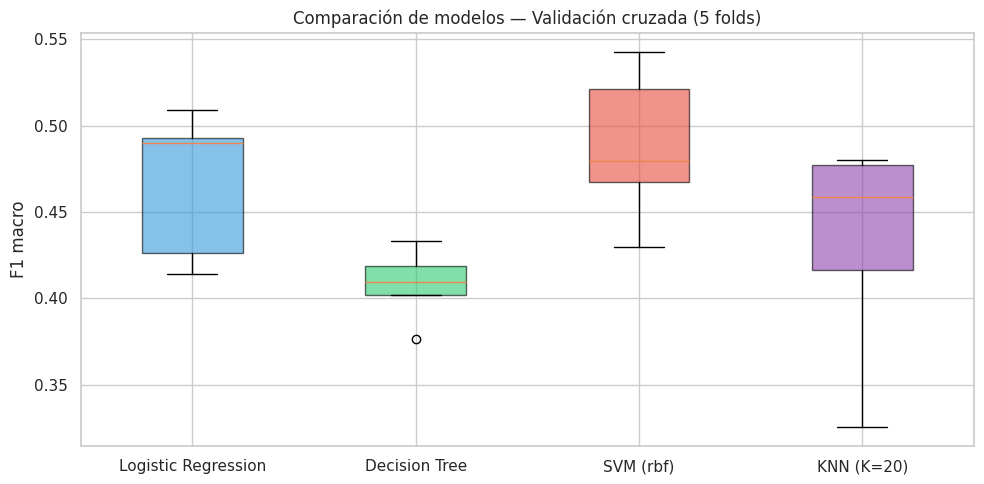

In [25]:
filas = []
for nombre, y_p in pred_test.items():
    filas.append({
        'Modelo': nombre,
        'F1 macro CV (media)': resultados_cv[nombre].mean(),
        'F1 macro CV (std)': resultados_cv[nombre].std(),
        'Accuracy test': accuracy_score(y_test_e, y_p),
        'F1 macro test': f1_score(y_test_e, y_p, average='macro'),
        'F1 weighted test': f1_score(y_test_e, y_p, average='weighted')
    })

tabla_comp = pd.DataFrame(filas).set_index('Modelo').round(4)
print('=' * 80)
print('COMPARACIÓN DE MODELOS')
print('=' * 80)
print(f'Referencia (siempre la clase mayoritaria): accuracy = {baseline_acc:.4f}')
display(tabla_comp.style.background_gradient(cmap='YlGn', axis=0))

# Boxplot de la validación cruzada
nombres = list(resultados_cv.keys())
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot([resultados_cv[n] for n in nombres], tick_labels=nombres, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1 macro')
ax.set_title('Comparación de modelos — Validación cruzada (5 folds)')
plt.tight_layout()
plt.show()

**Paso 15 — F1 por clase y matrices de confusión**

Se calcula el F1 de cada clase para cada modelo y se muestra en un mapa de calor, para ver qué niveles de desempeño son más difíciles. Luego se grafican las 4 matrices de confusión juntas: al ser una escala ordenada (`Average` < `Good` < `Vg` < `Excellent`), lo esperable es que los errores caigan en las celdas vecinas a la diagonal.

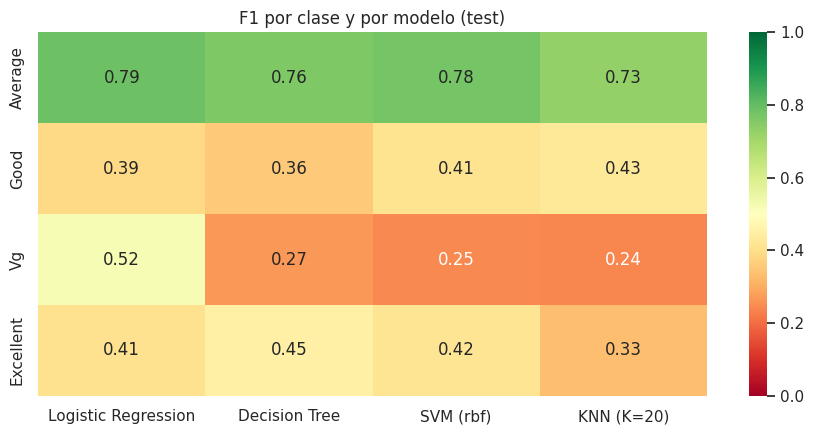

,Logistic Regression,Decision Tree,SVM (rbf),KNN (K=20),Soporte (test)
Average,0.788,0.761,0.776,0.730,30
Good,0.387,0.357,0.411,0.429,39
Vg,0.521,0.269,0.246,0.239,36
Excellent,0.408,0.451,0.415,0.333,20


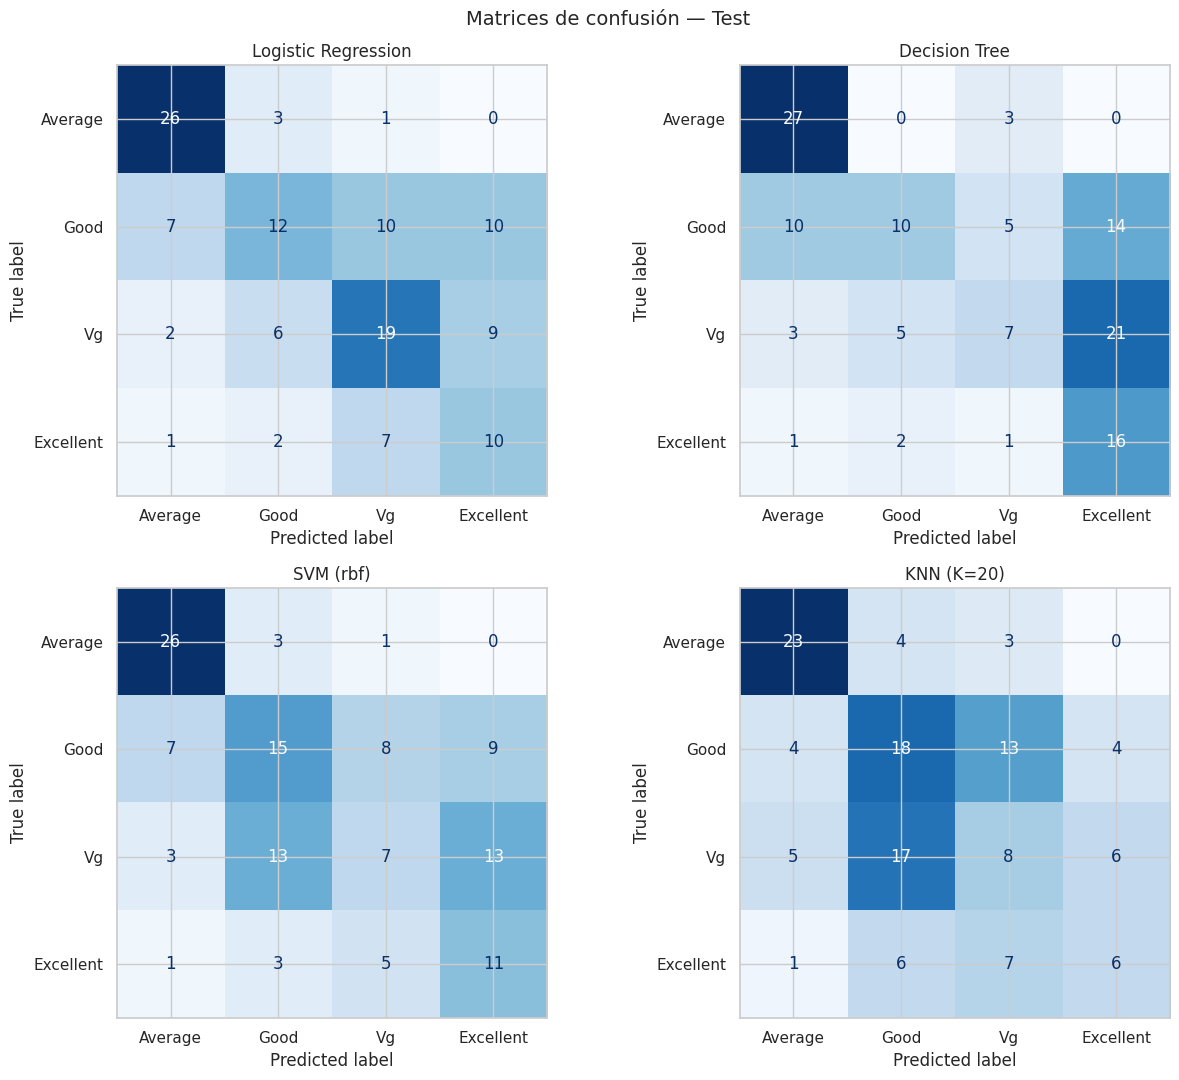

In [26]:
# 15.1 F1 por clase
f1_clase = pd.DataFrame(
    {n: f1_score(y_test_e, p, labels=orden_p, average=None, zero_division=0)
     for n, p in pred_test.items()},
    index=orden_p
)
soporte = [int((y_test_e == c).sum()) for c in orden_p]

plt.figure(figsize=(9, 4.5))
sns.heatmap(f1_clase, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1)
plt.title('F1 por clase y por modelo (test)')
plt.tight_layout()
plt.show()

f1_mostrar = f1_clase.copy()
f1_mostrar['Soporte (test)'] = soporte
display(f1_mostrar.round(3))

# 15.2 Matrices de confusión
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (nombre, y_p) in zip(axes.flatten(), pred_test.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_e, y_p, labels=orden_p, cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(nombre)
fig.suptitle('Matrices de confusión — Test', fontsize=14)
plt.tight_layout()
plt.show()

**Paso 16 — Análisis de sensibilidad: ¿cuánto depende el desempeño de `Caste`?**

`Caste` fue la variable dominante en tres análisis distintos: la V de Cramér (0.468, más del doble que la siguiente), los coeficientes de la Regresión Logística y la importancia del Árbol (0.793). Para medir cuánto sostiene el rendimiento de los modelos se comparan tres escenarios:

- **Todas las variables** (el análisis principal).
- **Sin `Caste`:** las otras 10 variables.
- **Solo `Caste`:** un modelo que usa únicamente esa variable.

Se mantienen los hiperparámetros ya elegidos (`max_depth=5`, kernel `rbf`, K=20) para que la comparación sea justa. Se reporta el F1 macro en validación cruzada y en test. El escenario "Todas" debe reproducir los resultados anteriores, lo que sirve de verificación.

Resultados por escenario:


,Escenario,Modelo,F1 macro CV,std CV,F1 macro test,Accuracy test
0,Todas,Logistic Regression,0.4664,0.0385,0.5259,0.536
1,Todas,Decision Tree,0.4079,0.0189,0.4594,0.480
2,Todas,SVM (rbf),0.4881,0.0400,0.4619,0.472
3,Todas,KNN (K=20),0.4317,0.0578,0.4327,0.440
4,Sin Caste,Logistic Regression,0.3486,0.0365,0.3769,0.376
5,Sin Caste,Decision Tree,0.2801,0.0634,0.3234,0.328
6,Sin Caste,SVM (rbf),0.3234,0.0525,0.3218,0.320
7,Sin Caste,KNN (K=20),0.2949,0.0370,0.3595,0.360
8,Solo Caste,Logistic Regression,0.3920,0.0292,0.4038,0.456
9,Solo Caste,Decision Tree,0.3920,0.0292,0.4038,0.456



F1 macro CV:


Escenario,Todas,Sin Caste,Solo Caste,Δ (Sin Caste − Todas)
Modelo,,,,
Decision Tree,0.4079,0.2801,0.3920,-0.1278
KNN (K=20),0.4317,0.2949,0.3362,-0.1369
Logistic Regression,0.4664,0.3486,0.3920,-0.1179
SVM (rbf),0.4881,0.3234,0.3920,-0.1648


F1 macro test:


Escenario,Todas,Sin Caste,Solo Caste,Δ (Sin Caste − Todas)
Modelo,,,,
Decision Tree,0.4594,0.3234,0.4038,-0.1360
KNN (K=20),0.4327,0.3595,0.3200,-0.0732
Logistic Regression,0.5259,0.3769,0.4038,-0.1490
SVM (rbf),0.4619,0.3218,0.4038,-0.1402


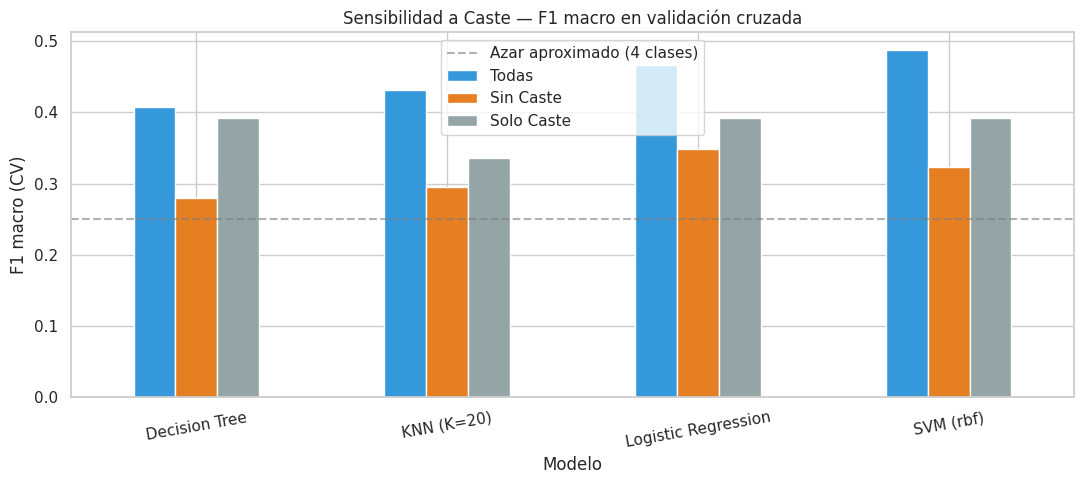

In [27]:
cat_ord = {'Class_X_Percentage': orden_p,
           'Class_XII_Percentage': orden_p,
           'time': orden_time}

def hacer_prep(noms, ords):
    """Preprocesador para un subconjunto de variables."""
    trans = []
    if ords:
        trans.append(('ord', Pipeline([
            ('ord', OrdinalEncoder(categories=[cat_ord[c] for c in ords])),
            ('scaler', StandardScaler())
        ]), ords))
    if noms:
        trans.append(('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), noms))
    return ColumnTransformer(trans)

def hacer_clasificadores():
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced',
                                                  random_state=RANDOM_STATE),
        'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                                class_weight='balanced', random_state=RANDOM_STATE),
        nombre_svm: SVC(kernel=best_kernel_e, class_weight='balanced', random_state=RANDOM_STATE),
        nombre_knn: KNeighborsClassifier(n_neighbors=best_k_e)
    }

escenarios = {
    'Todas':       (cols_nominales, cols_ordinales),
    'Sin Caste':   ([c for c in cols_nominales if c != 'Caste'], cols_ordinales),
    'Solo Caste':  (['Caste'], [])
}

filas = []
for esc, (noms, ords) in escenarios.items():
    cols_uso = noms + ords
    for nombre, clf in hacer_clasificadores().items():
        pipe = Pipeline([('prep', hacer_prep(noms, ords)), ('clf', clf)])
        cvs = cross_val_score(pipe, X_train_e[cols_uso], y_train_e, cv=cv, scoring='f1_macro')
        pipe.fit(X_train_e[cols_uso], y_train_e)
        yp = pipe.predict(X_test_e[cols_uso])
        filas.append({
            'Escenario': esc, 'Modelo': nombre,
            'F1 macro CV': cvs.mean(), 'std CV': cvs.std(),
            'F1 macro test': f1_score(y_test_e, yp, average='macro'),
            'Accuracy test': accuracy_score(y_test_e, yp)
        })

sens = pd.DataFrame(filas)

print('Resultados por escenario:')
display(sens.round(4))

# Tablas comparativas (modelos en filas, escenarios en columnas)
cv_tab = sens.pivot(index='Modelo', columns='Escenario', values='F1 macro CV')[['Todas', 'Sin Caste', 'Solo Caste']]
cv_tab['Δ (Sin Caste − Todas)'] = cv_tab['Sin Caste'] - cv_tab['Todas']
print('\nF1 macro CV:')
display(cv_tab.round(4))

te_tab = sens.pivot(index='Modelo', columns='Escenario', values='F1 macro test')[['Todas', 'Sin Caste', 'Solo Caste']]
te_tab['Δ (Sin Caste − Todas)'] = te_tab['Sin Caste'] - te_tab['Todas']
print('F1 macro test:')
display(te_tab.round(4))

# Gráfico
cv_tab[['Todas', 'Sin Caste', 'Solo Caste']].plot(kind='bar', figsize=(11, 5),
                                                  color=['#3498db', '#e67e22', '#95a5a6'])
plt.axhline(0.25, color='gray', linestyle='--', alpha=0.6, label='Azar aproximado (4 clases)')
plt.ylabel('F1 macro (CV)')
plt.title('Sensibilidad a Caste — F1 macro en validación cruzada')
plt.xticks(rotation=10)
plt.legend()
plt.tight_layout()
plt.show()

**Paso 17 — Conclusiones del Ejercicio 3**

**1. Resumen de resultados (dataset sin duplicados: 622 registros, 497 en train y 125 en test)**

| Modelo | F1 macro CV | F1 macro test | Accuracy test |
|---|---|---|---|
| Regresión Logística | 0.4664 ± 0.0385 | 0.5259 | 0.536 |
| Árbol de Decisión (prof. 5) | 0.4079 ± 0.0189 | 0.4594 | 0.480 |
| SVM (rbf) | 0.4881 ± 0.0400 | 0.4619 | 0.472 |
| KNN (K=20) | 0.4317 ± 0.0578 | 0.4327 | 0.440 |

Como referencia, predecir siempre la clase mayoritaria da un accuracy de 0.312.

**2. Rendimiento general**

Los cuatro modelos superan la referencia, pero el rendimiento es moderado (F1 macro CV entre 0.41 y 0.49). Hay un techo natural: 42 combinaciones de features aparecen con más de una etiqueta, es decir, estudiantes con el mismo perfil terminan en distinto nivel de desempeño. Además, el dataset es pequeño y todas las variables son categóricas con pocos niveles.

**3. Comparación de modelos**

- El **SVM (rbf)** es el mejor en validación cruzada y la **Regresión Logística** es la mejor en test, pero la diferencia entre ambos está dentro del ruido (desviación estándar en CV de unos 0.04 y solo 125 muestras en test), por lo que no se puede declarar un ganador único.
- El **Árbol de Decisión** y **KNN** quedan por debajo. El árbol depende casi por completo de `Caste` (importancia de 0.793) y no usa las notas de las clases X y XII. Cambiar su profundidad no ayuda: la mejor profundidad (6) da un F1 macro CV de 0.4121, apenas por encima del 0.4079 de la profundidad 5. KNN no tiene `class_weight`, así que favorece a las clases grandes.
- La **estandarización** casi no importa aquí (+1.50 puntos en el SVM, dentro de la desviación estándar), a diferencia de Wine Quality (+25 puntos). Las 35 columnas del one-hot ya valen 0 o 1, y el escalado solo afecta a 3 columnas ordinales. La importancia del escalado depende del tipo de variables.
- La elección de hiperparámetros tampoco es concluyente: los 5 mejores valores de K (entre 0.422 y 0.432) están todos dentro de su desviación estándar.

**4. Rendimiento por clase**

- `Average` es la más fácil para todos los modelos (F1 entre 0.73 y 0.79).
- `Good` es difícil para todos (F1 entre 0.36 y 0.43).
- `Vg` es donde más difieren: la Regresión Logística logra 0.52 y los otros tres entre 0.24 y 0.27. Con solo 36 muestras en test, parte de la diferencia puede ser azar.
- `Excellent` (F1 entre 0.33 y 0.45) tiene solo 20 muestras en test, por lo que sus métricas son muy inestables. Con `class_weight='balanced'`, los modelos la predicen con frecuencia: recall alto (0.50 a 0.80) pero precision baja (0.31 a 0.34). KNN, sin ese ajuste, tiene el recall más bajo (0.30).

**5. Hallazgo principal: la dependencia de `Caste`**

| Modelo | Todas las variables | Sin `Caste` | Solo `Caste` |
|---|---|---|---|
| Regresión Logística | 0.4664 | 0.3486 | 0.3920 |
| Árbol de Decisión | 0.4079 | 0.2801 | 0.3920 |
| SVM (rbf) | 0.4881 | 0.3234 | 0.3920 |
| KNN (K=20) | 0.4317 | 0.2949 | 0.3362 |

(F1 macro en validación cruzada. Un F1 macro de 0.25 es lo esperable al adivinar según las proporciones de las clases.)

- `Caste` fue la variable dominante en cuatro análisis independientes: la V de Cramér (0.468, más del doble que la siguiente), los coeficientes de la Regresión Logística, la importancia del Árbol y este análisis de sensibilidad.
- Sin `Caste`, el F1 macro CV cae entre 11.8 y 16.5 puntos, y tres de los cuatro modelos quedan cerca del azar.
- `Caste` sola alcanza 0.392, casi lo mismo que el Árbol con todas las variables. Las demás variables aportan entre 7 y 10 puntos adicionales a la Regresión Logística, el SVM y KNN, principalmente en combinación con `Caste`.
- Tres modelos dan resultados idénticos con `Caste` sola porque una variable de 4 categorías solo genera 4 entradas distintas, y con `class_weight='balanced'` predicen lo mismo para cada casta.

**6. Consideraciones éticas**

Esta relación es una asociación estadística, no una causa. Una posible explicación son los cupos de admisión, pero esa es una hipótesis que estos datos no permiten confirmar. Además, el dataset solo incluye candidatos que aprobaron el examen de ingreso, lo que puede generar asociaciones que no existen en la población general. Un modelo que use pertenencia social para predecir el desempeño de una persona no debería emplearse para tomar decisiones sobre individuos.

**7. Limitaciones**

- Dataset pequeño (622 registros tras quitar 44 duplicados), con solo 20 muestras de `Excellent` en test.
- Los hiperparámetros se eligieron por validación cruzada sobre los mismos folds que se usaron para comparar, lo que da estimaciones algo optimistas.
- En el análisis de sensibilidad se mantuvieron los hiperparámetros originales, sin reajustarlos para cada subconjunto de variables.
- Las etiquetas contradictorias imponen un techo al rendimiento que ningún modelo puede superar.

**8. Conclusión final**

Con este dataset, la Regresión Logística y el SVM ofrecen el mejor rendimiento (F1 macro CV de 0.47 a 0.49), pero la diferencia entre ellos no es concluyente. Lo más importante no es qué modelo gana, sino que los cuatro dependen de `Caste` para predecir el desempeño. Sin ella, casi no superan el azar. Para mejorar el resultado harían falta más datos, sobre todo de la clase `Excellent`, y variables con más información sobre el desempeño académico.